In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import datetime as dt
%matplotlib inline
import os
import sys
from tqdm import tqdm
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from opendrift.readers import reader_netCDF_CF_generic
from opendrift.readers import reader_global_landmask
import opendrift.readers as readers
from opendrift.models.oceandrift import OceanDrift
from datetime import timedelta
from scipy.interpolate import griddata

ModuleNotFoundError: No module named 'opendrift'

In [ ]:
hfr_files, hfr_filepaths = tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/HFR/','nc_files',file_end='nc')
hfr = xr.open_mfdataset(hfr_filepaths)

In [1]:
path_tohd = '/media/basil/Elements/data/Thesis/LLC4320/nc_files/'

model_uv = xr.open_dataset(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc').isel(k=0)
lcs_model = xr.open_dataset('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

NameError: name 'xr' is not defined

In [4]:
u_model = model_uv.sel(time='2012-01-01').isel(time=4)['u'].where(model_uv.lon>-126)
v_model = model_uv.sel(time='2012-01-01').isel(time=4)['v'].where(model_uv.lon>-126)

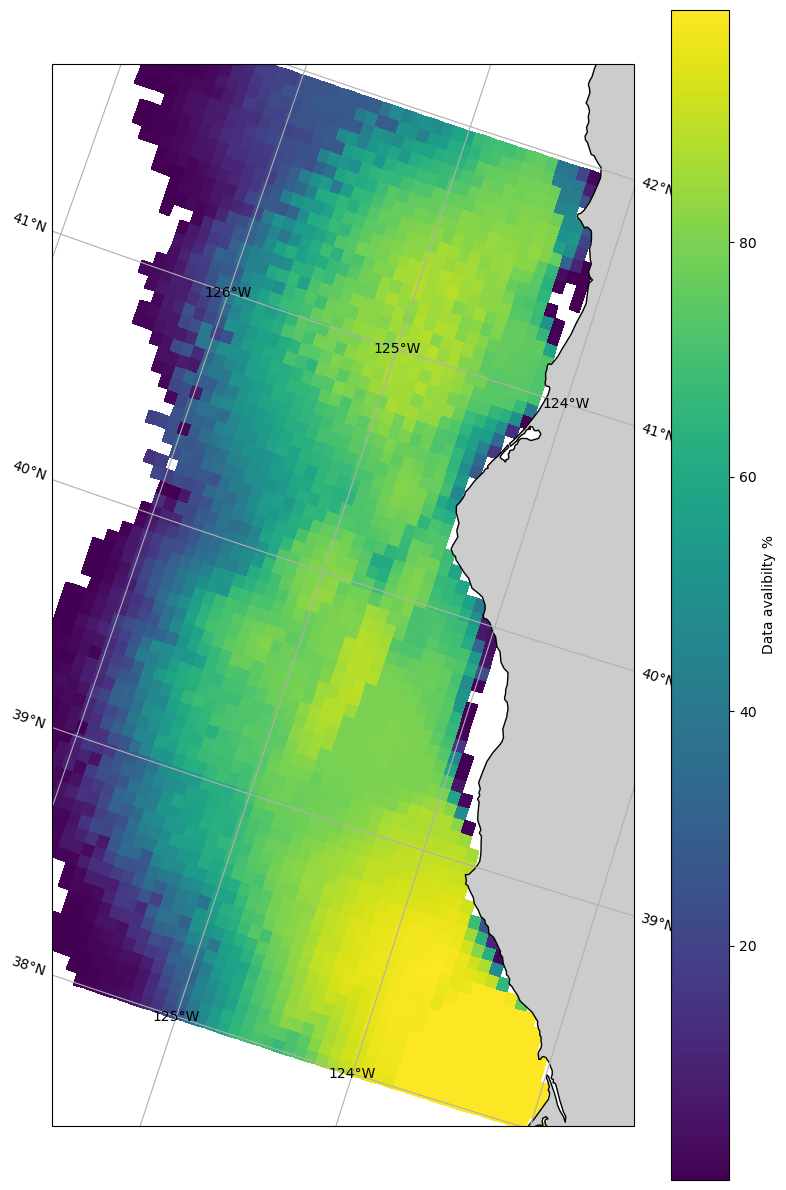

In [11]:
finite_values = np.isfinite(hfr['u'])
spatial_var = finite_values.sum(dim={'time'})/len(finite_values.time)

spatial_var = spatial_var.where(spatial_var != 0)
#masks_greater90 = spatial_var.where(((spatial_var>.85)))
tools.map_capemend(spatial_var*100, labelz = 'Data avalibilty %',figsize=(8,12))
plt.savefig('./Data_avalibility.png')
#(spatial_var*100).plot(alpha=.75,cbar_kwargs={'label':'Data avalibilty %'})
# plt.xlim(-127,-123)
# plt.ylim(38,42)

In [6]:
o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o.set_config('general:coastline_action', 'previous') 
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:time_step_minutes', 60)
o.set_config('drift:stokes_drift', False)
#o.set_config('seed:ocean_only', True)
o.set_config('general:use_auto_landmask', False)
#o.set_config('environment:fallback:land_binary_mask', 1)
o_diffusion.set_config('general:coastline_action', 'stranding') 
o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
o_diffusion.set_config('general:time_step_minutes', 60)
o_diffusion.set_config('drift:stokes_drift', False)
o_diffusion.set_config('drift:current_uncertainty_uniform', 0)
o_diffusion.set_config('general:use_auto_landmask', False)
reader_data = reader_netCDF_CF_generic.Reader(hfr)
reader_landmask = reader_global_landmask.Reader()
#reader_landmask.activate_environment_mapping('land_binary_mask_from_ocean_depth')
#reader_data.activate_environment_mapping('land_binary_mask_from_ocean_depth')
o.add_reader([reader_data,reader_landmask])
o_diffusion.add_reader([reader_data,reader_landmask])

In [12]:
lcs = o.calculate_ftle( 
    time=reader_data.start_time + timedelta(hours=0),
    time_step=timedelta(minutes=30),
    duration=timedelta(hours=6), delta_x=0.06246948,delta_y=.05393982,reader=reader_data,
    RLCS=True)

18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values after 10 iterations, exiting!
18:01:32 WARNING opendrift:133: Still NaN-values aft

In [13]:
lcs_lat = lcs['lat']
lcs_lon = lcs['lon']
alcs_time = lcs['time']
alcs_data = lcs['ALCS'].data
time = alcs_time
lat = lcs_lat[:,0]
lon = lcs_lon[0,:]
rlcs_data = lcs['RLCS'].data

ALCS = xr.DataArray(alcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='ALCS')
RLCS = xr.DataArray(rlcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='RLCS')

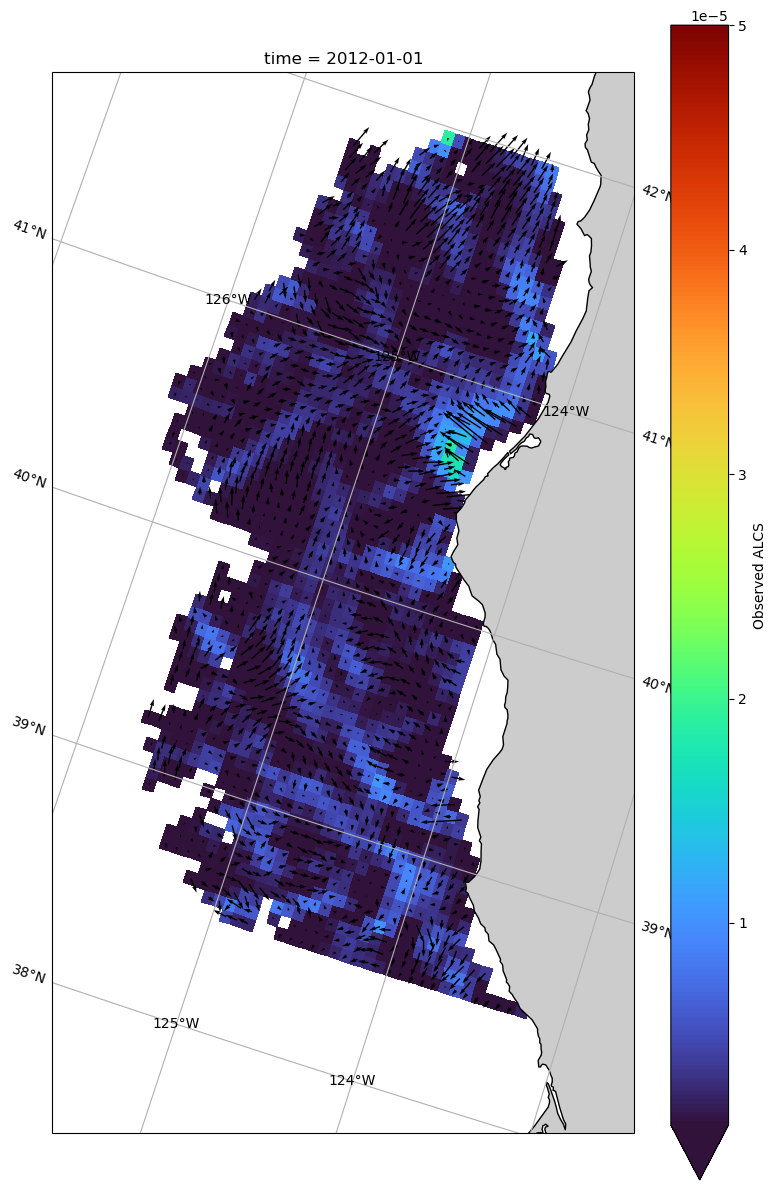

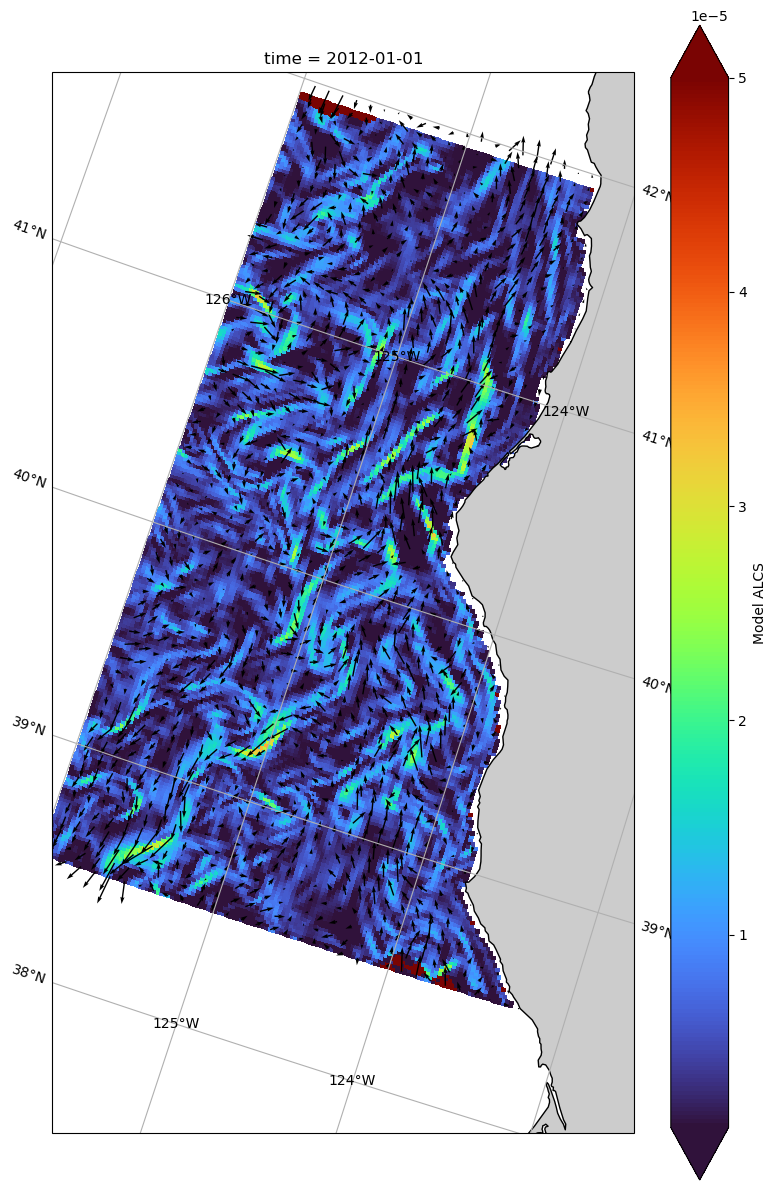

In [14]:
#hfr.isel(time=0)['u'].plot()

FTLE_threshold = [1e-6,5e-5] #Attracting


tools.map_capemend(hfr.sel(lat=slice(38.5,42)).isel(time=4)['u'],hfr.sel(lat=slice(38.5,42)).isel(time=4)['v'],ALCS.isel(time=0).where(np.array(np.isfinite(hfr['u'].isel(time=4)[:,:-1]))).sel(lat=slice(38.5,42)), scl=10,zmin = FTLE_threshold[0],zmax=FTLE_threshold[1],colorstyle='turbo',labelz = 'Observed ALCS',figsize=(8,12))
plt.tight_layout()
plt.savefig('./Observed_lcs.png')
tools.map_capemend(u_model[::4,::4],v_model[::4,::4],lcs_model['ALCS'].sel(lon=slice(-126,-123),time='2012-01-01').isel(time=0), scl=10,zmin = FTLE_threshold[0],zmax=FTLE_threshold[1],colorstyle='turbo',labelz = 'Model ALCS', figsize=(8,12))
plt.tight_layout()

plt.savefig('./Model_lcs.png')
